# Initialization

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_tools import hyperbolic, drawtools, coxeter, automata, representation
from numpy import pi, log
from scipy.optimize import bisect

# Algorithm

Algorithm to estimate critical exponent using expanding Markov partition is from McMullen's paper ["Hausdorff dimension and conformal dynamics III: Computation of dimension"](https://people.math.harvard.edu/~ctm/papers/home/text/papers/dimIII/dimIII.pdf)

Algorithm to estimate conformal density (of dimension = critical exponent) is from Gittins--Peyerimhoff--Stociu--Wirosoetisno, ["Some spectral applications of McMullen's Hausdorff dimension algorithm"](https://arxiv.org/pdf/1112.1020) (see Section 3.2)

## Common auxiliary functions 

In [4]:
# Auxiliary functions for Fuchsian and Kleinian cases
# Possibly more general, not sure yet

def mobius_transform(mat, pt):
    if np.abs(pt) == np.inf:
        if mat[1,0] == 0: return np.inf
        else: return mat[0,0] / mat[1,0]
    elif (mat[1,0]*pt + mat[1,1]) == 0:
        return np.inf
    else:
        return (mat[0,0]*pt + mat[0,1]) / (mat[1,0]*pt + mat[1,1])

def mobius_derivative(mat, pt):
# This actually returns derivative / determinant
# To find actual derivative, multiply by determinant
    if np.abs(pt) == np.inf: 
        if mat[1,0] == 0: return mat[1,1]**(-2)
        else: return 0
    elif mat[1,0]*pt+mat[1,1] == 0: return np.inf 
    else: return (mat[1,0]*pt + mat[1,1])**(-2)

In [5]:
# Auxiliary numerical linear algebra functions

def spectral_radius(M):
    return max(abs(np.linalg.eigvals(M)))

def estimate_delta(T, smin=0.1, smax=5.0, tol=1e-6):
    """
    Solve ρ(T**s) = 1 by bisection.
    """
    return bisect(lambda s: spectral_radius(T**s)-1, smin, smax, xtol=tol)

## Auxiliary functions for Fuchsian computations

In [7]:
psiDH = np.array([[-1j,1],[1,-1j]])
psiHD = np.array([[-1,1j],[1j,-1]])
# note these are only inverses up to scalar (their product is 2i*I)
# this doesn't matter for Mobius transformations
# but it does introduce a factor of 4 when taking derivatives

def conjugate_HD(mat):
    return psiHD @ mat @ psiDH    

#def conformal_DtoH(w):
#    return mobius_transform(np.array([[-1j,1],[1,-1j]]),w)
#def conformal_HtoD(w):
#    return mobius_transform(np.array([[-1,1j],[1j,-1]]),w)

def R_to_circ(x):
    return np.angle(mobius_transform(psiHD, x)) % (2*np.pi)

def circ_to_R(theta):
    return mobius_transform(psiDH, np.exp(theta*1j))

def circle_derivative(mat, pt):
    circ_pt = mobius_transform(psiHD, pt)
    r = -4* mobius_derivative(psiDH, circ_pt)
    r *= mobius_derivative(mat, pt)
    r *= mobius_derivative(psiHD, mobius_transform(mat, pt))
    return r

## Primary functions for Fuchsian case

In [20]:
def transition_matrix(maps, sample_points, block_intersects):
    """
    Compute the transition matrix T_ij for a Markov partition.
    """
    N = len(maps)
    T = np.zeros((N, N))  # Transition matrix

    for i in range(N):
        for j in range(N):
            if j in block_intersects[i]:
                y_ij = mobius_transform(np.linalg.inv(maps[i]), sample_points[j])
                # T[i,j] = 1 / np.abs(circle_derivative(maps[i],y_ij)) # if doing computations in the half-plane
                T[i,j] = 0.25 / np.abs(mobius_derivative(maps[i],y_ij))
    return T

# Kleinian case should be identical

In [ ]:
def refine_partition(maps, sample_points, block_intersects):
    N = len(maps)
    new_maps, new_sample_points, new_intersects = [], [], []
    intersect_list = []
    
    for i in range(N):
        for j in range(N):
            if j in block_intersects[i]: intersect_list += [(i,j)] 
    
    for i in range(N):
        for j in range(N):
            if j in block_intersects[i]:
                # Assign map i to new block Rij
                new_maps += [maps[i]]
                # Assign sample point to new block Rij
                new_sample_points += [mobius_transform(np.linalg.inv(maps[i]),sample_points[j])]

                new_intersects += [[intersect_list.index((j,k)) for k in block_intersects[j]]]
    return new_maps, new_sample_points, new_intersects

# Kleinian case should be identical


In [10]:
def approximate_measure(Ts, sample_points, I):
    """
    Compute conformal density using Perron-Frobenius eigenvector of transition matrix.
    
    Here Ts is the exponentiated transition matrix, and I is an interval on the real line whose measure is to be computed.
    """
    eigenvalues, eigenvectors = np.linalg.eig(Ts)
    max_index = np.argmax(np.real(eigenvalues))
    largest_eigenvector = np.real(eigenvectors[:, max_index])
    PF_eigenvector = largest_eigenvector / np.sum(largest_eigenvector)
    
    deltas_in = [PF_eigenvector[i] for i in range(len(PF_eigenvector)) if I[0] < sample_points[i] < I[1]]
    return np.sum(deltas_in)

# This is general except for 
# (a) how we specify the subset (I = interval, for the Fuchsian case)
# (b) how we check sample points are in the given subset (now specific to Fuchsian case)

## Functions for Kleinian case (pre-unification)

In [ ]:
def approximate_measure(Ts, sample_points, z, R):
    """
    Compute conformal density using Perron-Frobenius eigenvector of transition matrix.
    
    Here Ts is the exponentiated transition matrix, and we return the measure of a ball of radius R centered at z.
    """
    eigenvalues, eigenvectors = np.linalg.eig(Ts)
    max_index = np.argmax(np.real(eigenvalues))
    largest_eigenvector = np.real(eigenvectors[:, max_index])
    PF_eigenvector = largest_eigenvector / np.sum(largest_eigenvector)
    
    deltas_in = [PF_eigenvector[i] for i in range(len(PF_eigenvector)) if np.abs(sample_points[i]-z) < R]
    return np.sum(deltas_in)

# This is general except for 
# (a) how we specify the subset (currently: balls on the Riemann sphere?)
# (b) how we check sample points are in the given subset (to figure out ...)

## Common core

In [19]:
# Main loop for estimating critical exponent

def estimate_critexp(maps, sample_points, block_intersects, iterations=3, verbose=True):
    if verbose: 
        delta = estimate_delta(transition_matrix(maps, sample_points, block_intersects)) 
        print(f"Initial estimate of critical exponent = {delta}.")
    for i in range(1,iterations):
        maps, sample_points, block_intersects = refine_partition(maps, sample_points, block_intersects)
        if verbose:
            T = transition_matrix(maps, sample_points, block_intersects)
            delta = estimate_delta(T) 
            print(f"Using level-{i} refinement of partition, estimated critical exponent = {delta}.")
    if not verbose:
        T = transition_matrix(maps, sample_points, block_intersects)
        delta = estimate_delta(T)
    return delta, sample_points, T

# Examples

## Fuchsian Schottky group

### Initialization

In [11]:
# Initialize group 
# Schottky group (nonabelian free group of rank 2)
# # from Mangahas chapter on ping-pong in Office Hours with a Geometric Group Theorist
rep = representation.Representation()
rep["a"] = np.array([[3, 0], [0, 1/3]], dtype=np.float64)
rep["b"] = np.array([[5/3, 4/3], [4/3, 5/3]], dtype=np.float64)

In [31]:
# Specify Markov partition data

#blocks = [(.5, 4.5),(4.5, -4.5), (-4.5, -.5), (-.5,.5)]
# Those are the blocks, but we only need the combinatorics of how their translates intersect.
block_intersects = [[0,1,3],[0,1,2],[1,2,3],[0,2,3]]

#maps = [rep["B"],rep["A"],rep["b"],rep["a"]]
#sample_points = [circ_to_R(z) for z in [0, np.pi/2+0.01, np.pi, np.pi/2*3]]

# To do computations directly on unit circle
maps = [conjugate_HD(x) for x in [rep["B"],rep["A"],rep["b"],rep["a"]]]
sample_points = [np.exp(theta*1j) for theta in [0, np.pi/2+0.01, np.pi, np.pi/2*3]]

# note: infinity and values near infinity are tricky, so we avoid this by doing small perturbations

### Estimate $\delta$ and $\mu$

In [21]:
delta, sps, T = estimate_critexp(maps, sample_points, block_intersects, iterations=6)    

Initial estimate of critical exponent = 0.6417174220085142.
Using level-1 refinement of partition, estimated critical exponent = 0.6512573599815367.
Using level-2 refinement of partition, estimated critical exponent = 0.6525844931602477.
Using level-3 refinement of partition, estimated critical exponent = 0.6527573943138122.
Using level-4 refinement of partition, estimated critical exponent = 0.6527795910835266.
Using level-5 refinement of partition, estimated critical exponent = 0.6527819275856017.


In [22]:
delta, sps, T = estimate_critexp(maps, sample_points, block_intersects, iterations=6, verbose=False)
delta

0.6527819275856017

In [23]:
# approximate_measure(T**delta, sps,[-.5,.5]) # if using computations in half-plane
approximate_measure(T**delta, np.angle(sps),[-.5,.5])

0.25000000894802155

### Visualization, numerical estimates

In [34]:
# Compute orbit of basepoint for all group elements of word-length up to 10.

pos_isometries = rep.freely_reduced_elements(10)
basepoint = 0 + 1j
    
orbit = [mobius_transform(mat, basepoint) for mat in pos_isometries]

In [ ]:
# Transform points in restricted orbit into hyperbolic.Point objects
# Takes ~1min for Mangahas group, words of up to length 10

orbit = [[pt.real, pt.imag] for pt in orbit]
orbit = [hyperbolic.Point(pt, model="halfplane") for pt in orbit]
basepoint = hyperbolic.Point((0,1), model="halfplane")
len(orbit)

118097

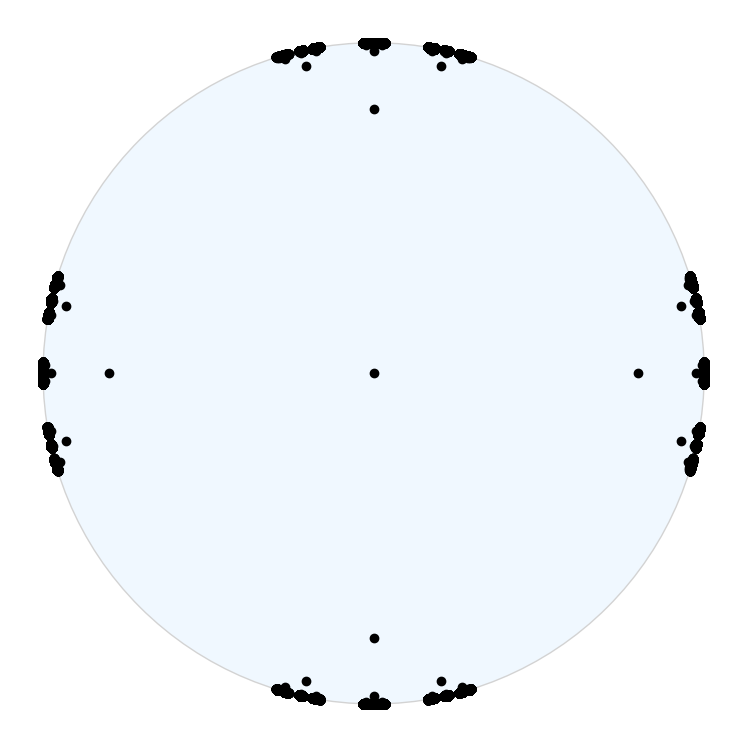

In [36]:
# Draw restricted orbit (takes ~5.5min for Manghas group, words of up to length 10)

figure = drawtools.HyperbolicDrawing()
figure.draw_plane()
for pt in orbit:
    figure.draw_point(pt)

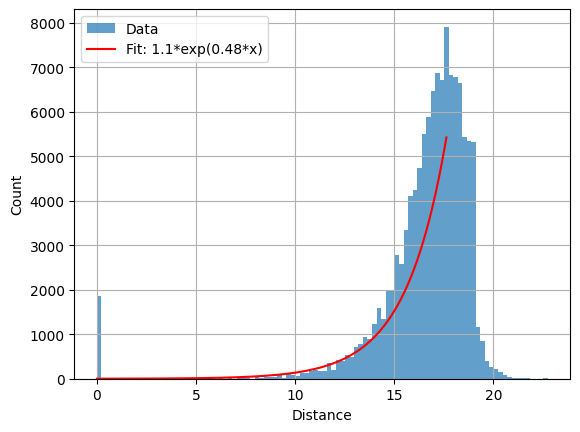

Fitted parameters: a = 1.09, b = 0.48


In [37]:
# Numerically approximate critical exponent using restricted orbit 

distances = [basepoint.distance(pt) for pt in orbit]
# Create histogram
counts, bins, _ = plt.hist(distances, bins=100, density=False, alpha=0.7, label='Data')
bin_centers = (bins[:-1] + bins[1:]) / 2

# Find peak index and use only data before it
peak_idx = np.argmax(counts)
x = bin_centers[:peak_idx+1]  # include the peak
counts_before_peak = counts[:peak_idx+1]

# Take logs of positive counts before peak
mask = counts_before_peak > 0
log_counts = np.log(counts_before_peak[mask])
x = x[mask]

# Fit line to log data
coeffs = np.polyfit(x, log_counts, 1)

# Convert back to exponential parameters
a = np.exp(coeffs[1])  # y-intercept becomes exp coefficient
b = coeffs[0]          # slope stays the same

# Generate points for the fitted curve
x_fit = np.linspace(min(bins), bin_centers[peak_idx], 1000)
y_fit = a * np.exp(b * x_fit)

# Plot original histogram and fit
plt.plot(x_fit, y_fit, 'r-', label=f'Fit: {a:.1f}*exp({b:.2f}*x)')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

print(f"Fitted parameters: a = {a:.2f}, b = {b:.2f}")

In [38]:
# approximate measure of [...]
crit_exp = b
# Filter to unit interval
filtered = [point for point in orbit if abs(point.halfspace_coords()[0]) < 1 and abs(point.halfspace_coords()[0]) < 1e-3]
print(len(filtered))

1105


In [39]:
dirac_sum = sum(np.exp(-crit_exp * basepoint.distance(point)) for point in filtered)
normalized = sum(np.exp(-crit_exp * basepoint.distance(point)) for point in orbit)
measure = dirac_sum / normalized
measure

0.0022449163180287067